## Preliminary data analysis

In [93]:
# Packages
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

In [ ]:
# Configuration for plotting
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'legend.fontsize': 16
})

In [ ]:
# Loading the data
metadata = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/metadata.csv")
meth = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/DNAm.csv")
cnv = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/cnv.csv")
rna = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/RNASeq.csv")

In [42]:
# Use sample names as rownames in metadaat
metadata = metadata.set_index("patient_id")

# Reformat sample names
cnv["sample_id"] = cnv["sample_id"].str.replace(".", "-", regex=False)
rna["sample_id"] = rna["sample_id"].str.replace(".", "-", regex=False)
meth["sample_id"] = meth["sample_id"].str.replace(".", "-", regex=False)

def shorten_tcga_id(x):
    
    parts = x.split("-")
    # TCGA barcode structure: sample-level ends at element 4
    # if there are more parts → strip last two
    if len(parts) > 4:
        return "-".join(parts[:4])
    return x

cnv["sample_id"] = cnv["sample_id"].apply(shorten_tcga_id)
rna["sample_id"] = rna["sample_id"].apply(shorten_tcga_id)
meth["sample_id"] = meth["sample_id"].apply(shorten_tcga_id)

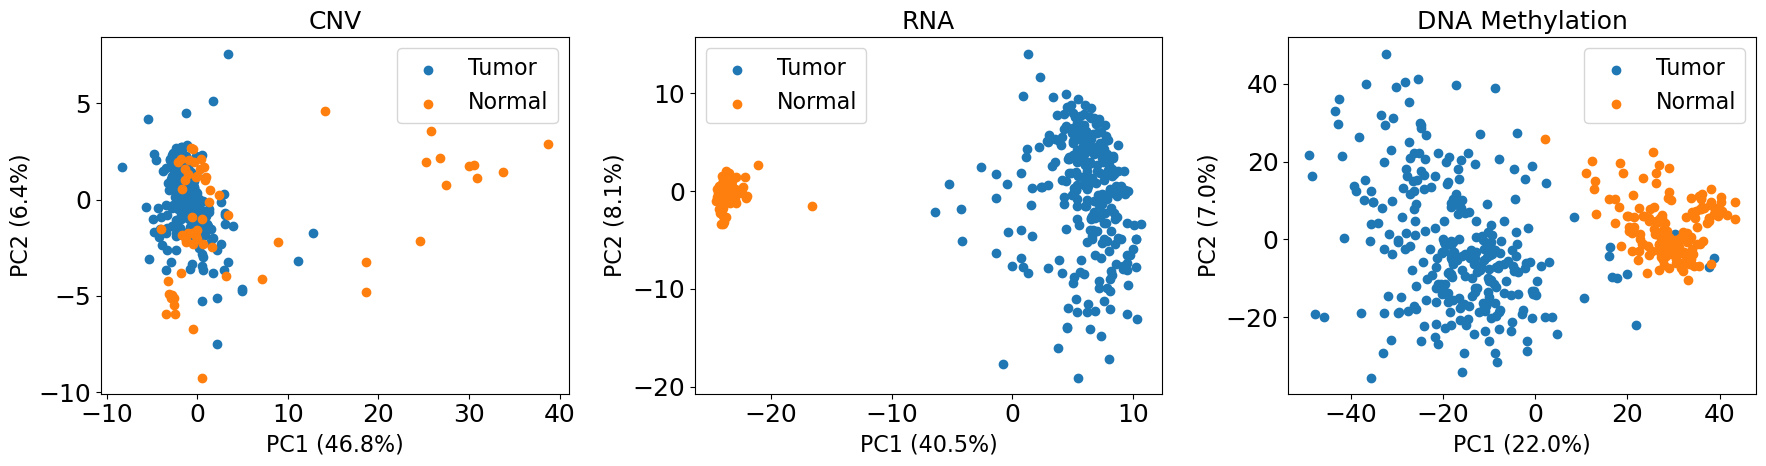

In [65]:
# PCA
pca = PCA(n_components=2)
pca_cnv = pca.fit_transform(cnv.drop(columns="sample_id"))
var_cnv = pca.explained_variance_ratio_

pca_rna = pca.fit_transform(rna.drop(columns="sample_id"))
var_rna = pca.explained_variance_ratio_

pca_meth = pca.fit_transform(meth.drop(columns="sample_id"))
var_meth = pca.explained_variance_ratio_


# Put into DataFrame
pca_df_cnv = pd.DataFrame(pca_cnv, columns=["PC1", "PC2"])
pca_df_cnv["sample_id"] = cnv["sample_id"].values
pca_df_cnv["status"] = metadata.loc[pca_df_cnv["sample_id"], "label"].values

pca_df_rna = pd.DataFrame(pca_rna, columns=["PC1", "PC2"])
pca_df_rna["sample_id"] = rna["sample_id"].values
pca_df_rna["status"] = metadata.loc[pca_df_rna["sample_id"], "label"].values

pca_df_meth = pd.DataFrame(pca_meth, columns=["PC1", "PC2"])
pca_df_meth["sample_id"] = meth["sample_id"].values
pca_df_meth["status"] = metadata.loc[pca_df_meth["sample_id"], "label"].values

# Change 0/1 to Normal/Tumor
pca_df_cnv["status"] = pca_df_cnv["status"].map({0: "Normal", 1: "Tumor"})
pca_df_rna["status"] = pca_df_rna["status"].map({0: "Normal", 1: "Tumor"})
pca_df_meth["status"] = pca_df_meth["status"].map({0: "Normal", 1: "Tumor"})

# Plotting
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
for s in pca_df_cnv["status"].dropna().unique():
    tmp = pca_df_cnv[pca_df_cnv["status"] == s]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=s)
plt.xlabel(f"PC1 ({var_cnv[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_cnv[1]*100:.1f}%)")
plt.title("CNV")
plt.legend()

plt.subplot(1,3,2)
for s in pca_df_rna["status"].dropna().unique():
    tmp = pca_df_rna[pca_df_rna["status"] == s]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=s)
plt.xlabel(f"PC1 ({var_rna[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_rna[1]*100:.1f}%)")
plt.title("RNA")
plt.legend()

plt.subplot(1,3,3)
for s in pca_df_meth["status"].dropna().unique():
    tmp = pca_df_meth[pca_df_meth["status"] == s]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=s)
plt.xlabel(f"PC1 ({var_meth[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_meth[1]*100:.1f}%)")
plt.title("DNA Methylation")
plt.legend()

plt.tight_layout()
plt.show()

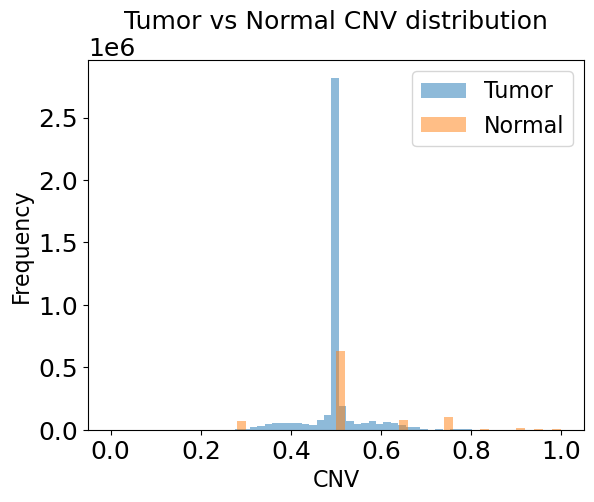

In [67]:
# DISTRIBUTION OF CNV

# Split data
group = metadata.loc[cnv["sample_id"], "label"].values
tumor = cnv[group == 1].drop(columns=["sample_id"])
normal = cnv[group == 0].drop(columns=["sample_id"])

# Flatten
tumor_vals = tumor.values.flatten()
normal_vals = normal.values.flatten()

plt.figure()

plt.hist(tumor_vals, bins=50, alpha=0.5, label="Tumor")
plt.hist(normal_vals, bins=50, alpha=0.5, label="Normal")

plt.title("Tumor vs Normal CNV distribution")
plt.xlabel("CNV")
plt.ylabel("Frequency")
plt.legend()

plt.show()

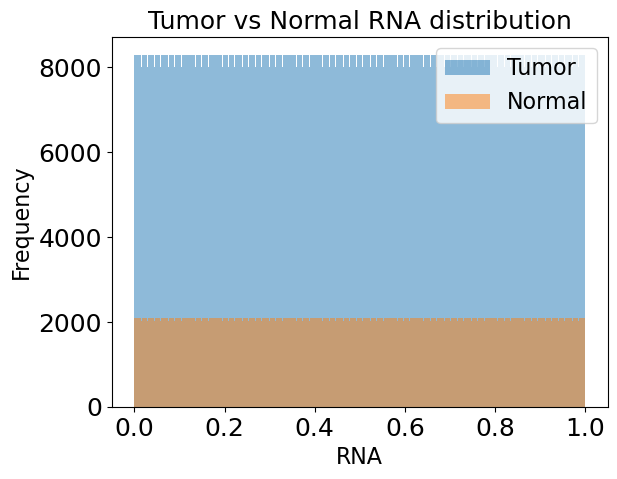

In [68]:
# DISTRIBUTION OF RNA (The min/max normalization has erased all diferences)

# Split data
group = metadata.loc[rna["sample_id"], "label"].values
tumor = rna[group == 1].drop(columns=["sample_id"])
normal = rna[group == 0].drop(columns=["sample_id"])

# Flatten
tumor_vals = tumor.values.flatten()
normal_vals = normal.values.flatten()

plt.figure()

plt.hist(tumor_vals, bins=500, alpha=0.5, label="Tumor")
plt.hist(normal_vals, bins=500, alpha=0.5, label="Normal")

plt.title("Tumor vs Normal RNA distribution")
plt.xlabel("RNA")
plt.ylabel("Frequency")
plt.legend()

plt.show()

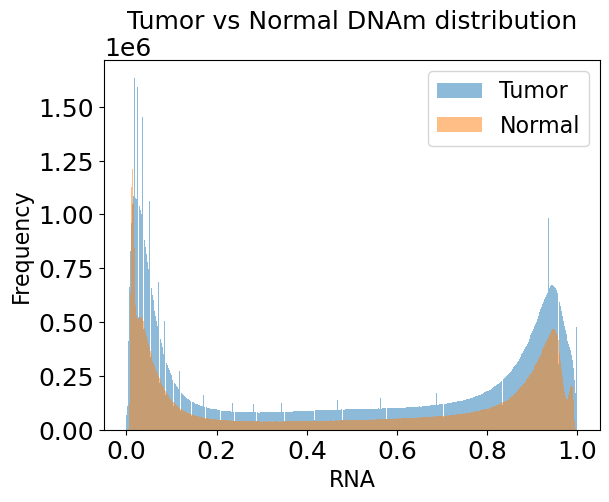

In [156]:
# DISTRIBUTION OF RNA

# Split data
group = metadata.loc[meth["sample_id"], "label"].values
tumor = meth[group == 1].drop(columns=["sample_id"])
normal = meth[group == 0].drop(columns=["sample_id"])

# Flatten
tumor_vals = tumor.values.flatten()
normal_vals = normal.values.flatten()

plt.figure()

plt.hist(tumor_vals, bins=500, alpha=0.5, label="Tumor")
plt.hist(normal_vals, bins=500, alpha=0.5, label="Normal")

plt.title("Tumor vs Normal DNAm distribution")
plt.xlabel("RNA")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [69]:
# Differential CNV / Expression / Methylation

# Define function
def differential_analysis(labels, matrix, adjustment_method="bonferroni"):

    results = []

    # ensure numpy/pandas alignment
    labels = np.array(labels)

    for gene in matrix.columns:
        groups = np.unique(labels)
        group1 = matrix.loc[labels == groups[0], gene]
        group2 = matrix.loc[labels != groups[0], gene]
        stat, p = ranksums(group1, group2)
        diff_in_medians = np.median(group1) - np.median(group2)

        results.append((gene, stat, p, diff_in_medians))
    df = pd.DataFrame(results, columns=["gene", "stat", "p_value", "diff_in_medians"])

    # multiple testing correction (BH or others)
    reject, p_adj, _, _ = multipletests(df["p_value"], method=adjustment_method)
    df["p_adj"] = p_adj
    df["significant"] = reject
    return df.sort_values("p_adj")

In [70]:
# Differential gene expression
my_labels = metadata.loc[rna["sample_id"],"label"].values
my_genes = rna.drop(columns="sample_id")

gex_differential_analysis = differential_analysis(my_labels, my_genes)

significant_gex = gex_differential_analysis[gex_differential_analysis["p_adj"] < 0.05]
print("Number of significant transcripts {}".format(len(significant_gex)))

Number of significant transcripts 11441


In [71]:
# Differential copy number
my_labels = metadata.loc[cnv["sample_id"],"label"].values
my_cnv = cnv.drop(columns="sample_id")

cnv_differential_analysis = differential_analysis(my_labels, my_cnv)

significant_cnv = cnv_differential_analysis[cnv_differential_analysis["p_adj"] < 0.05]
print("Number of significant genes by CNV {}".format(len(significant_cnv)))

Number of significant genes by CNV 13830


In [73]:
# Differential methylation
my_labels = metadata.loc[meth["sample_id"],"label"].values
my_meth = meth.drop(columns="sample_id")

meth_differential_analysis = differential_analysis(my_labels, my_meth)

significant_cpgs = meth_differential_analysis[meth_differential_analysis["p_adj"] < 0.05]
print("Number of significant cpgs {}".format(len(significant_cpgs)))

Number of significant cpgs 230022


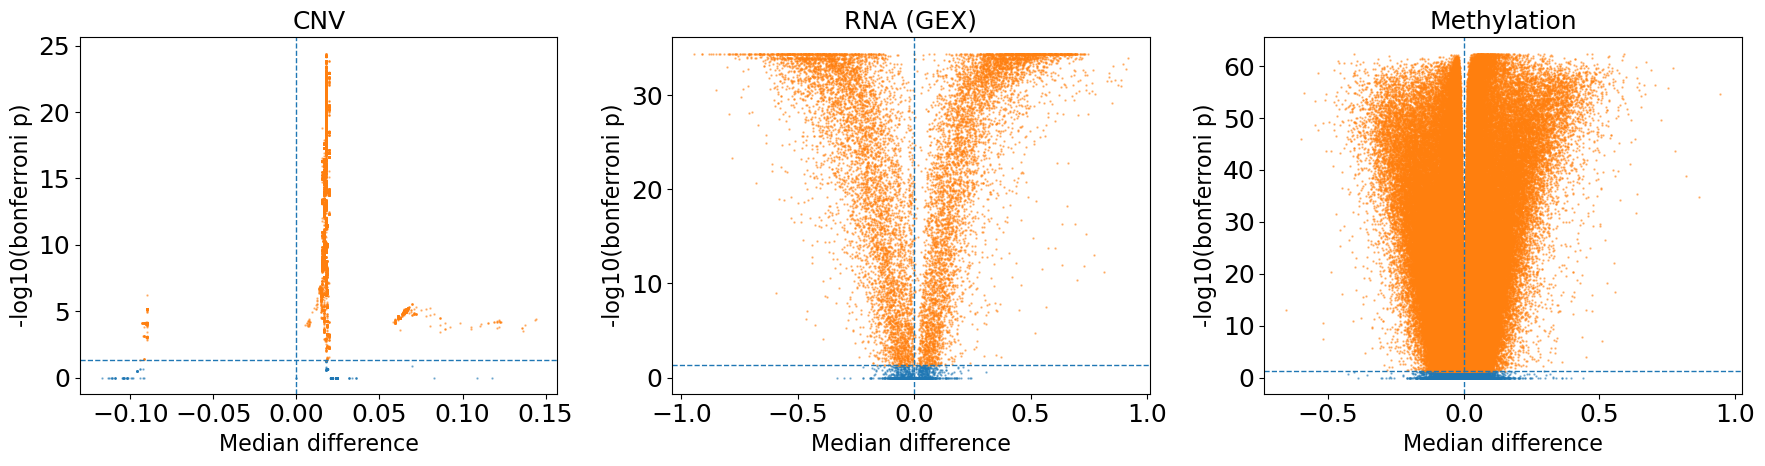

In [157]:
def volcano(ax, df, title, p_adj_th = 0.05, effect_size_th = 0):

    effect = df["diff_in_medians"]
    neg_log_p = -np.log10(df["p_adj"] + 1e-300)
    sig = (df["p_adj"] < p_adj_th) & (np.abs(df["diff_in_medians"]) > effect_size_th)

    ax.scatter(effect[~sig], neg_log_p[~sig], alpha=0.5, s=0.5)
    ax.scatter(effect[sig], neg_log_p[sig], alpha=0.5, s=0.5)

    ax.axhline(-np.log10(0.05), linestyle="--", linewidth=1)
    ax.axvline(0, linestyle="--", linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("Median difference")
    ax.set_ylabel("-log10(bonferroni p)")


plt.figure(figsize=(18,5))

ax1 = plt.subplot(1,3,1)
volcano(ax1, cnv_differential_analysis, "CNV", p_adj_th = 0.05, effect_size_th = 0)

ax2 = plt.subplot(1,3,2)
volcano(ax2, gex_differential_analysis, "RNA (GEX)", p_adj_th = 0.05, effect_size_th = 0)

ax3 = plt.subplot(1,3,3)
volcano(ax3, meth_differential_analysis, "Methylation", p_adj_th = 0.05, effect_size_th = 0)

plt.tight_layout()
plt.show()

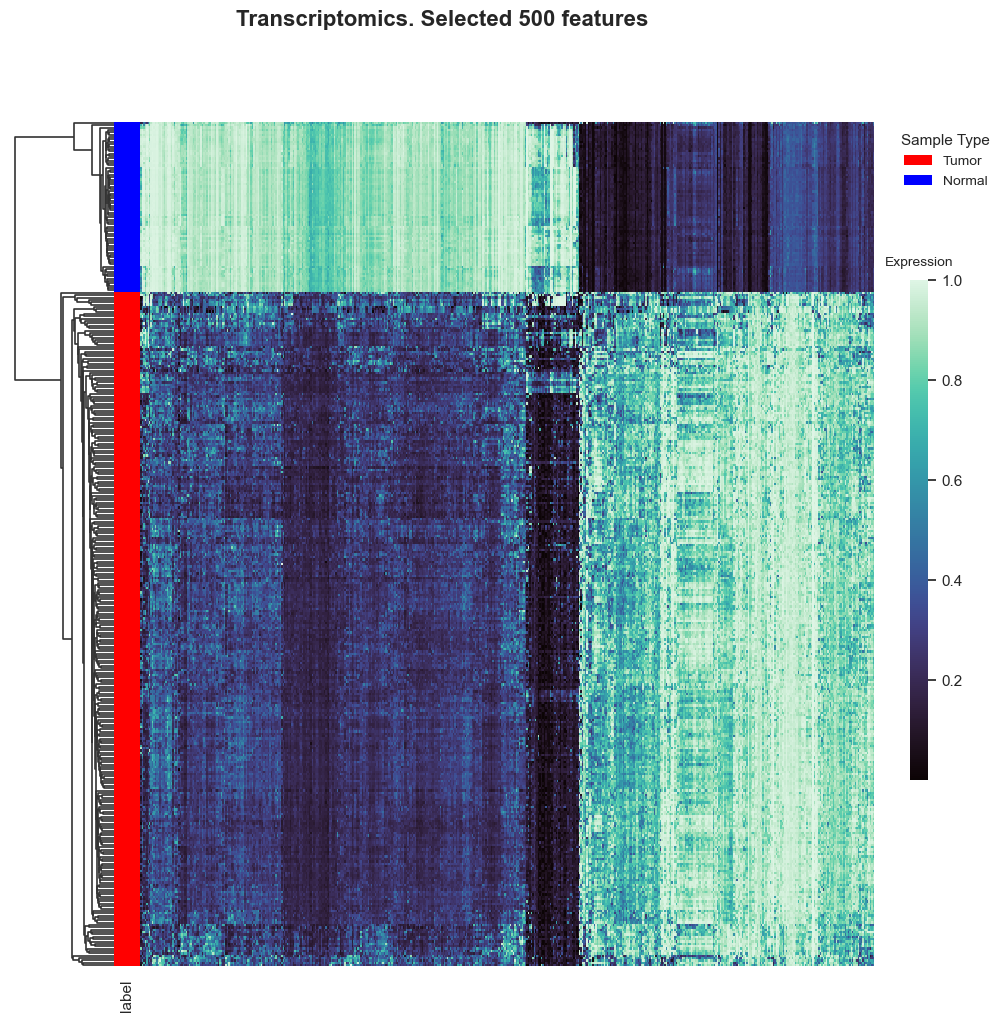

In [201]:
# Top genes RNA
gex_differential_analysis["score"] = (
    np.abs(gex_differential_analysis["diff_in_medians"])
    * (-np.log10(gex_differential_analysis["p_adj"] + 1e-300))
)

gex_differential_analysis = gex_differential_analysis.sort_values(
    by="score",
    ascending=False)

top_genes_GEX = gex_differential_analysis.head(500)["gene"]

# Subset expression matrix
gex_subset = rna.loc[:, top_genes_GEX].copy()

# Sample labels
labels = metadata.loc[rna["sample_id"], "label"].values

# Add labels
gex_subset["label"] = labels
gex_subset["label"] = gex_subset["label"].map({0: "Normal", 1: "Tumor"})

# Separate matrix and annotation
plot_df = gex_subset.drop(columns="label")
labels = gex_subset["label"]

# Color mapping
label_colors = {
    "Tumor": "red",
    "Normal": "blue"
}

row_colors = labels.map(label_colors)

# Clustermap
sns.set_theme(style="white")

g = sns.clustermap(
    plot_df,
    cmap="mako",                  
    row_colors=row_colors,
    yticklabels=False,
    xticklabels=False,
    figsize=(9, 10),
    linewidths=0,
    dendrogram_ratio=(0.12, 0.08),
    colors_ratio=0.03,
    cbar_pos=(0.92, 0.2, 0.02, 0.45),   # move colorbar fully outside
    tree_kws={"linewidths": 1.2}
)

g.cax.set_position([1.02, 0.25, 0.02, 0.5])

# --- remove unnecessary column dendrogram ---
g.ax_col_dendrogram.set_visible(False)

# --- cleaner colorbar ---
g.cax.set_title("Expression", fontsize=10, pad=10)

# --- legend ---
legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=label)
    for label, color in label_colors.items()
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Sample Type",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

# --- clean axes ---
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# --- title ---
g.fig.suptitle(
    "Transcriptomics. Selected 500 features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.show()

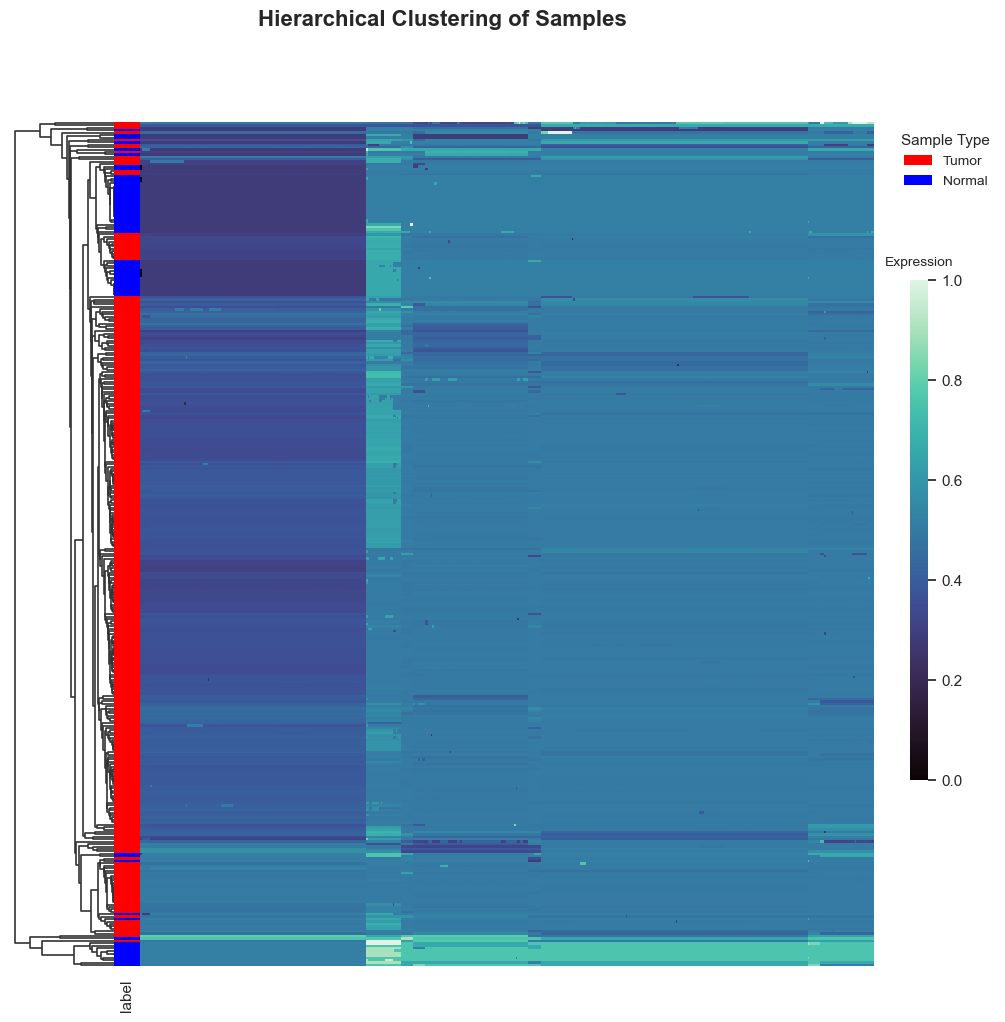

In [ ]:
# Top genes CNV
cnv_differential_analysis["score"] = (
    np.abs(cnv_differential_analysis["diff_in_medians"])
    * (-np.log10(cnv_differential_analysis["p_adj"] + 1e-300))
)

cnv_differential_analysis = cnv_differential_analysis.sort_values(
    by="score",
    ascending=False)

top_genes_CNV = cnv_differential_analysis.head(500)["gene"]

# Subset expression matrix
cnv_subset = cnv.loc[:, top_genes_CNV].copy()

# Sample labels
labels = metadata.loc[cnv["sample_id"], "label"].values

# Add labels
cnv_subset["label"] = labels
cnv_subset["label"] = cnv_subset["label"].map({0: "Normal", 1: "Tumor"})

# Separate matrix and annotation
plot_df = cnv_subset.drop(columns="label")
labels = cnv_subset["label"]

# Color mapping
label_colors = {
    "Tumor": "red",
    "Normal": "blue"
}

row_colors = labels.map(label_colors)

# Clustermap
sns.set_theme(style="white")

g = sns.clustermap(
    plot_df,
    cmap="mako",                  
    row_colors=row_colors,
    yticklabels=False,
    xticklabels=False,
    figsize=(9, 10),
    linewidths=0,
    dendrogram_ratio=(0.12, 0.08),
    colors_ratio=0.03,
    cbar_pos=(0.92, 0.2, 0.02, 0.45),   # move colorbar fully outside
    tree_kws={"linewidths": 1.2}
)

g.cax.set_position([1.02, 0.25, 0.02, 0.5])

# --- remove unnecessary column dendrogram ---
g.ax_col_dendrogram.set_visible(False)

# --- cleaner colorbar ---
g.cax.set_title("Expression", fontsize=10, pad=10)

# --- legend ---
legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=label)
    for label, color in label_colors.items()
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Sample Type",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

# --- clean axes ---
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# --- title ---
g.fig.suptitle(
    "CNV. Selected 500 features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.show()

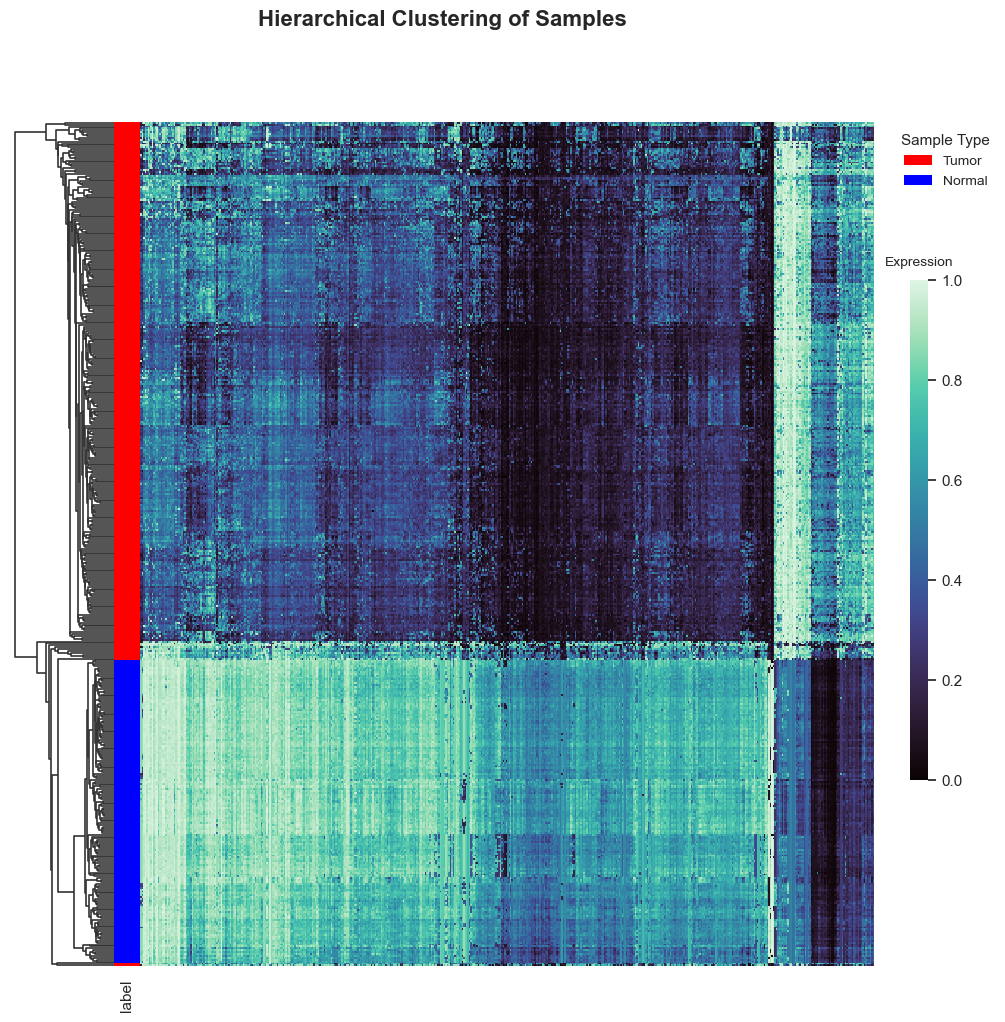

In [ ]:
# Top genes DNAm
meth_differential_analysis["score"] = (
    np.abs(meth_differential_analysis["diff_in_medians"])
    * (-np.log10(meth_differential_analysis["p_adj"] + 1e-300))
)

meth_differential_analysis = meth_differential_analysis.sort_values(
    by="score",
    ascending=False)

top_genes_METH = meth_differential_analysis.head(500)["gene"]

# Subset expression matrix
meth_subset = meth.loc[:, top_genes_METH].copy()

# Sample labels
labels = metadata.loc[meth["sample_id"], "label"].values

# Add labels
meth_subset["label"] = labels
meth_subset["label"] = meth_subset["label"].map({0: "Normal", 1: "Tumor"})

# Separate matrix and annotation
plot_df = meth_subset.drop(columns="label")
labels = meth_subset["label"]

# Color mapping
label_colors = {
    "Tumor": "red",
    "Normal": "blue"
}

row_colors = labels.map(label_colors)

# Clustermap
sns.set_theme(style="white")

g = sns.clustermap(
    plot_df,
    cmap="mako",                  
    row_colors=row_colors,
    yticklabels=False,
    xticklabels=False,
    figsize=(9, 10),
    linewidths=0,
    dendrogram_ratio=(0.12, 0.08),
    colors_ratio=0.03,
    cbar_pos=(0.92, 0.2, 0.02, 0.45),   # move colorbar fully outside
    tree_kws={"linewidths": 1.2}
)

g.cax.set_position([1.02, 0.25, 0.02, 0.5])

# --- remove unnecessary column dendrogram ---
g.ax_col_dendrogram.set_visible(False)

# --- cleaner colorbar ---
g.cax.set_title("Expression", fontsize=10, pad=10)

# --- legend ---
legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=label)
    for label, color in label_colors.items()
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Sample Type",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

# --- clean axes ---
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# --- title ---
g.fig.suptitle(
    "DNA methylation. Selected 500 features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.show()

In [193]:
# Combine into one dataframe
top_genes_df = pd.DataFrame({
    "GEX": top_genes_GEX.values,
    "METH": top_genes_METH.values,
    "CNV": top_genes_CNV.values
})

# Export
top_genes_df.to_csv("top_genes_multiomics.csv", index=False)